In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
df = pd.read_csv('car_evaluation.csv')
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1594 non-null   object
 1   maint     1594 non-null   object
 2   doors     1594 non-null   int64 
 3   persons   1594 non-null   int64 
 4   lug_boot  1594 non-null   object
 5   safety    1594 non-null   object
 6   class     1594 non-null   object
dtypes: int64(2), object(5)
memory usage: 87.3+ KB


In [ ]:
num = df.select_dtypes(include=np.number)
cat = df.select_dtypes(exclude=np.number)

,buying,maint,lug_boot,safety,class
count,1594,1594,1594,1594,1594
unique,4,4,3,3,2
top,vhigh,vhigh,small,low,unacc
freq,432,432,555,576,1210


In [16]:
for i in cat.columns:
    cek = df[i].value_counts()
    print(cek)

buying
vhigh    432
high     432
med      383
low      347
Name: count, dtype: int64
maint
vhigh    432
high     419
med      383
low      360
Name: count, dtype: int64
lug_boot
small    555
med      527
big      512
Name: count, dtype: int64
safety
low     576
med     537
high    481
Name: count, dtype: int64
class
unacc    1210
acc       384
Name: count, dtype: int64


In [17]:
df.duplicated().sum()

np.int64(0)

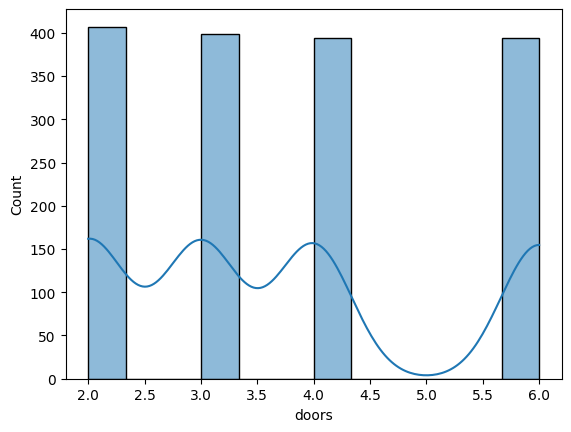

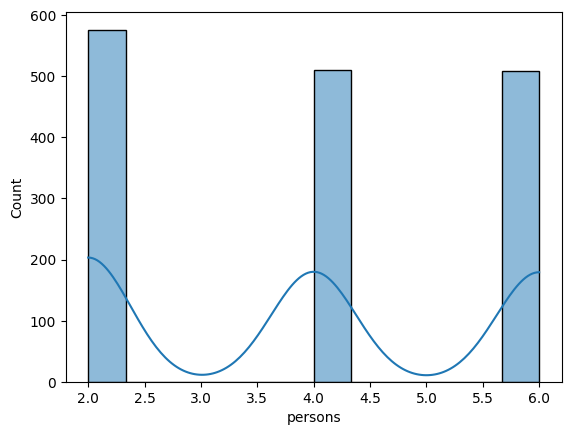

In [23]:
for i in num.columns:
    sns.histplot(data = df, x=i, kde=True)
    plt.show()

Unique values in buying : ['vhigh' 'high' 'med' 'low']
Unique values in maint : ['vhigh' 'high' 'med' 'low']
Unique values in lug_boot : ['small' 'med' 'big']
Unique values in safety : ['low' 'med' 'high']
Unique values in class : ['unacc' 'acc']


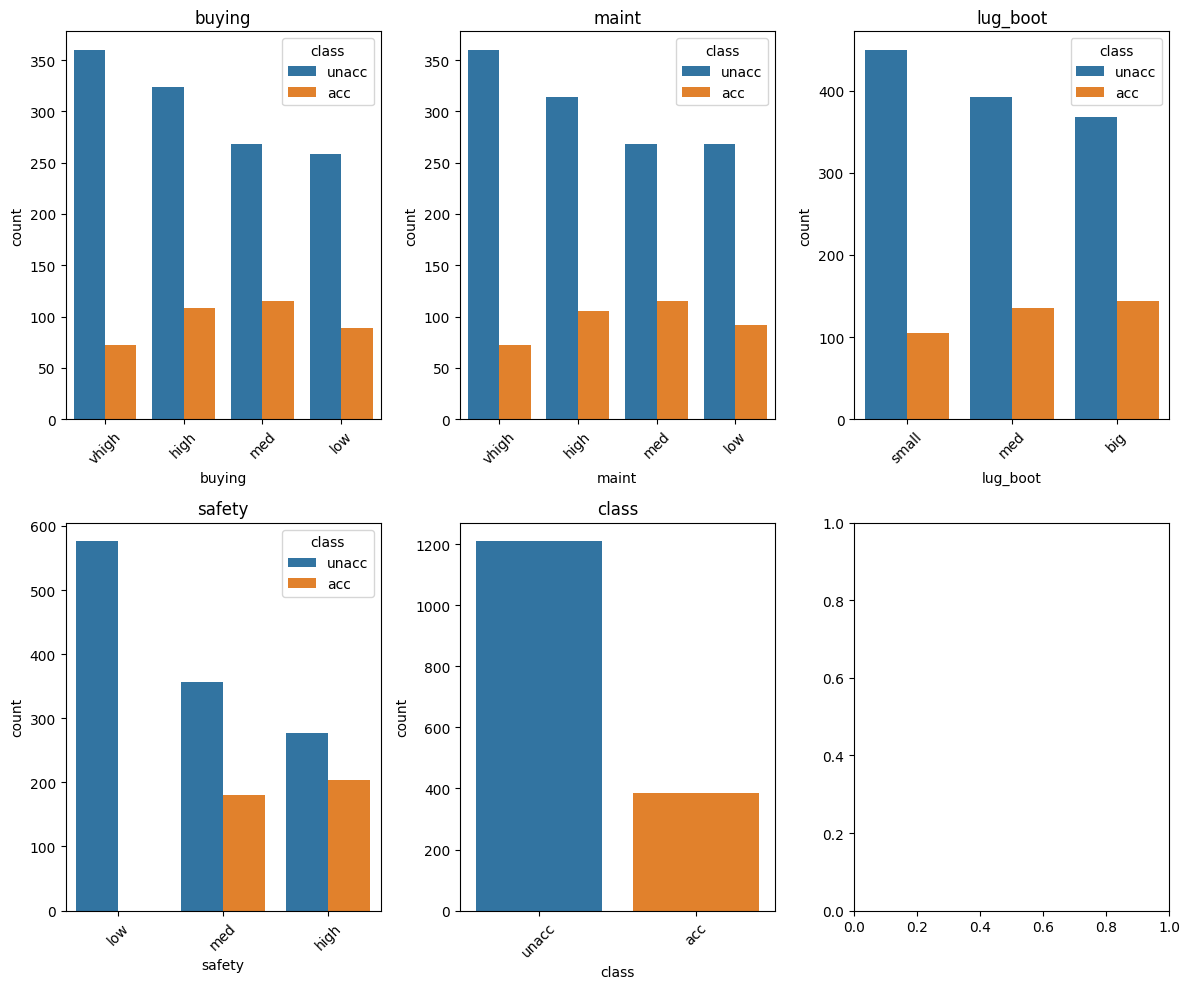

In [29]:
import math

n_cols = 3
n_rows = math.ceil(len(cat.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat.columns):
    print(f'Unique values in {col} : {cat[col].unique()}')

    sns.countplot(data=df, x=col, ax=axes[i], hue='class')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

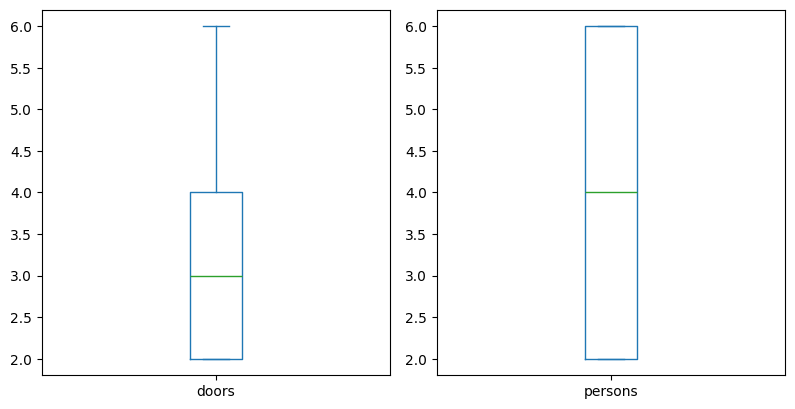

In [30]:
df.plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 8))
plt.tight_layout()
plt.show()

## Encode

In [31]:
low_high = {
    'low': 0,
    'med': 1,
    'high': 2,
    'vhigh': 3
}

small_big = {
    'small': 0,
    'med': 1,
    'big': 2
}

class_map = {
    'unacc': 0,
    'acc': 1,
}

for col in ['buying', 'maint', 'safety']:
    df[col] = df[col].map(low_high)

df['lug_boot'] = df['lug_boot'].map(small_big)
df['class'] = df['class'].map(class_map)

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,2,2,0,0,0
1,3,3,2,2,0,1,0
2,3,3,2,2,0,2,0
3,3,3,2,2,1,0,0
4,3,3,2,2,1,1,0


In [33]:
df['class'].value_counts(normalize=True)

class
0    0.759097
1    0.240903
Name: proportion, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,buying,maint,doors,persons,lug_boot,safety
1547,0,0,3,2,1,2
1511,0,1,6,2,2,0
744,2,1,6,4,2,0
462,2,3,3,2,1,0
1357,0,2,2,2,0,2
...,...,...,...,...,...,...
1130,1,1,4,2,0,1
1294,0,3,3,6,0,2
860,2,0,6,6,1,2
1459,0,1,2,4,0,0


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(X_train)

vif_df = (pd.DataFrame(
    [vif(X.values, i) for i in range(len(X.columns))],
    index=X.columns).reset_index())

vif_df.columns = ['feature', 'vif']
vif_df = vif_df.loc[vif_df['feature'] != 'const']
vif_df

,feature,vif
1,buying,1.018971
2,maint,1.009422
3,doors,1.000768
4,persons,1.010400
5,lug_boot,1.005221
6,safety,1.015215


In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5)

X_smote_train,  y_smote_train = smote.fit_resample(X_train, y_train)

In [39]:
y_smote_train.value_counts()

class
0    954
1    477
Name: count, dtype: int64

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_smote_train, y_smote_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = gbc.predict(X_train)
y_pred_test = gbc.predict(X_test)

print(f'Akurasi pada data train : {gbc.score(X_train, y_train)}')
print(f'Akurasi pada data test : {gbc.score(X_test, y_test)}')
print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

Akurasi pada data train : 0.9913725490196078
Akurasi pada data test : 0.987460815047022
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       954
           1       0.97      1.00      0.98       321

    accuracy                           0.99      1275
   macro avg       0.98      0.99      0.99      1275
weighted avg       0.99      0.99      0.99      1275

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       256
           1       0.94      1.00      0.97        63

    accuracy                           0.99       319
   macro avg       0.97      0.99      0.98       319
weighted avg       0.99      0.99      0.99       319



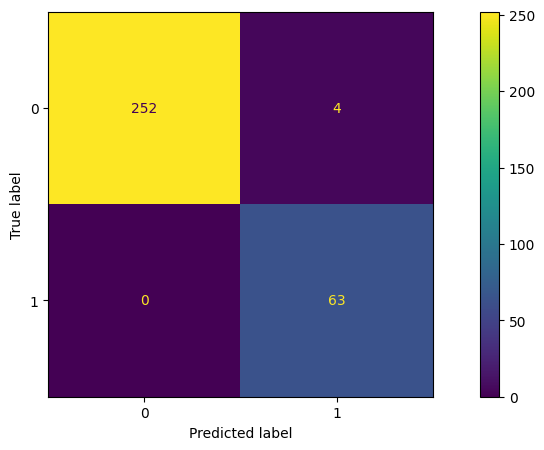

In [45]:
fig, axes = plt.subplots(figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_test, labels = gbc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gbc.classes_)

disp.plot(ax=axes)
plt.show()